In [ ]:
# =========================================================
# IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from google.colab import files

# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv('/content/student_mental_health_burnout.csv')

# menghapus spasi tersembunyi
df.columns = df.columns.str.strip()

print("Jumlah Data :", df.shape)

print("\n5 Data Pertama")
display(df.head())

# =========================================================
# INFORMASI DATASET
# =========================================================

print(df.info())

print("\nNama Kolom Dataset")
print(df.columns.tolist())

print("\nMissing Value")
print(df.isnull().sum())

Jumlah Data : (150000, 20)

5 Data Pertama


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

In [ ]:
# =========================================================
# PREPROCESSING DATA
# =========================================================

print("\n================ PREPROCESSING DATA ================\n")

# 1. Hapus data duplikat
df = df.drop_duplicates()

# 2. Menangani missing value
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nPreprocessing selesai")
display(df.head())


================ PREPROCESSING DATA ================


Preprocessing selesai


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [ ]:
# =========================================================
# MENAMBAHKAN VARIABEL BARU
# =========================================================

# agar hasil random tetap sama
np.random.seed(42)

# =========================================================
# CODING HOURS PER DAY
# =========================================================

df['coding_hours_per_day'] = np.random.uniform(
    1,
    10,
    size=len(df)
)

# =========================================================
# ASSIGNMENT DEADLINE PRESSURE
# =========================================================

df['assignment_deadline_pressure'] = np.random.randint(
    1,
    11,
    size=len(df)
)

display(
    df[[
        'coding_hours_per_day',
        'assignment_deadline_pressure'
    ]].head()
)

,coding_hours_per_day,assignment_deadline_pressure
0,4.370861,3
1,9.556429,6
2,7.587945,2
3,6.387926,8
4,2.404168,4


In [ ]:
# =========================================================
# KONVERSI STRESS LEVEL
# =========================================================

stress_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

df['stress_level_num'] = (
    df['stress_level']
    .map(stress_mapping)
)

display(
    df[[
        'stress_level',
        'stress_level_num'
    ]].head()
)

,stress_level,stress_level_num
0,High,3
1,High,3
2,Low,1
3,High,3
4,High,3


In [ ]:
# =========================================================
# KONVERSI SLEEP QUALITY
# =========================================================

print(df['sleep_quality'].unique())

# =========================================================
# MAPPING SLEEP QUALITY
# =========================================================

sleep_mapping = {
    'Poor': 1,
    'Average': 2,
    'Good': 3
}

df['sleep_quality_num'] = (
    df['sleep_quality']
    .map(sleep_mapping)
)

display(
    df[[
        'sleep_quality',
        'sleep_quality_num'
    ]].head()
)

['Average' 'Poor' 'Good']


,sleep_quality,sleep_quality_num
0,Average,2
1,Poor,1
2,Good,3
3,Poor,1
4,Good,3


In [ ]:
# uploaded = files.upload()   # pilih hasil_saw.csv DAN hasil_edas.csv

df_saw  = pd.read_csv('/content/hasil_saw.csv')
df_edas = pd.read_csv('/content/hasil_edas.csv')

# Merge berdasarkan kolom Alternatif
df_perbandingan = pd.merge(df_saw, df_edas, on='Alternatif')
df_perbandingan = df_perbandingan.sort_values('Ranking_SAW').reset_index(drop=True)

print("=== PERBANDINGAN SAW vs EDAS ===")
display(df_perbandingan)

=== PERBANDINGAN SAW vs EDAS ===


,Alternatif,Skor_SAW,Ranking_SAW,Skor_EDAS,Ranking_EDAS
0,100009,0.624391,1,0.770590,2
1,100003,0.551854,2,0.853757,1
2,100010,0.530570,3,0.708960,3
3,100007,0.526944,4,0.336109,9
4,100001,0.459484,5,0.514538,6
5,100005,0.452511,6,0.433435,8
6,100004,0.446993,7,0.616487,4
7,100008,0.405668,8,0.435036,7
8,100002,0.398851,9,0.574351,5
9,100006,0.324773,10,0.075510,10


In [ ]:
# =========================================================
# STEP 7 — ANALISIS / SUMMARY
# =========================================================

# Cek apakah ranking sama atau berbeda
sama = (df_perbandingan['Ranking_SAW'] == df_perbandingan['Ranking_EDAS']).all()

print("""
=== ANALISIS PERBANDINGAN SAW vs EDAS ===

1. AKUISISI DATA
   Dataset  : Student Mental Health
   Alternatif: 10 mahasiswa (student_id)
   Kriteria : 10 kriteria (C1–C10)
   Bobot    : sama rata (0.10 per kriteria)

2. HASIL SAW
   Metode   : Simple Additive Weighting
   Proses   : normalisasi → perkalian bobot → penjumlahan
   Ranking 1: {}

3. HASIL EDAS
   Metode   : Evaluation based on Distance from Average
   Proses   : AV → PDA/NDA → SP/SN → NSP/NSN → AS
   Ranking 1: {}

4. ANALISIS HASIL
   Konsistensi ranking: {}
""".format(
    df_perbandingan.loc[df_perbandingan['Ranking_SAW']==1, 'Alternatif'].values[0],
    df_perbandingan.loc[df_perbandingan['Ranking_EDAS']==1, 'Alternatif'].values[0],
    "Kedua metode menghasilkan ranking yang SAMA" if sama
    else "Terdapat PERBEDAAN ranking antara SAW dan EDAS"
))


=== ANALISIS PERBANDINGAN SAW vs EDAS ===

1. AKUISISI DATA
   Dataset  : Student Mental Health
   Alternatif: 10 mahasiswa (student_id)
   Kriteria : 10 kriteria (C1–C10)
   Bobot    : sama rata (0.10 per kriteria)

2. HASIL SAW
   Metode   : Simple Additive Weighting
   Proses   : normalisasi → perkalian bobot → penjumlahan
   Ranking 1: 100009

3. HASIL EDAS
   Metode   : Evaluation based on Distance from Average
   Proses   : AV → PDA/NDA → SP/SN → NSP/NSN → AS
   Ranking 1: 100003

4. ANALISIS HASIL
   Konsistensi ranking: Terdapat PERBEDAAN ranking antara SAW dan EDAS



/tmp/ipykernel_6054/2706533351.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(alt, rotation=45, ha='right')


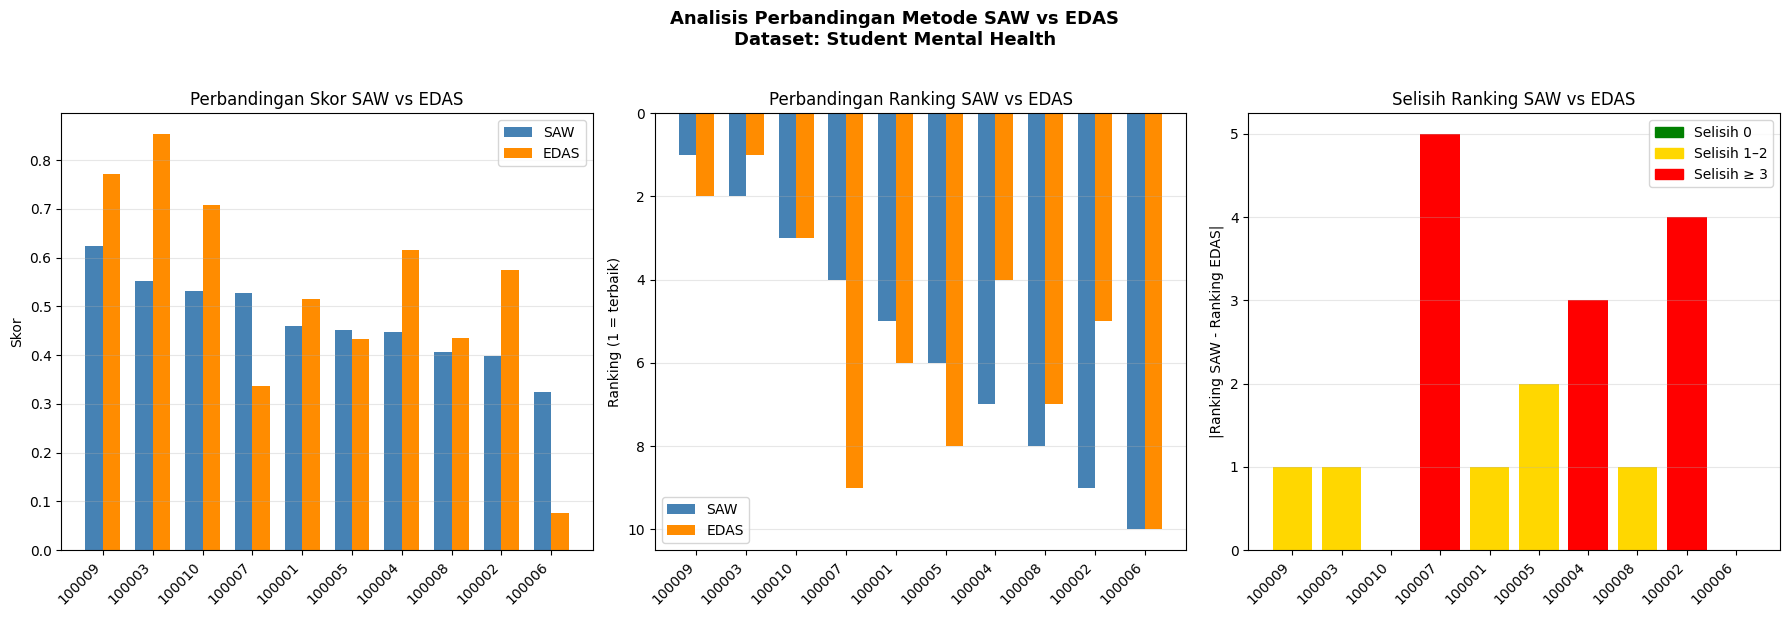

Chart berhasil disimpan: chart_perbandingan_saw_edas.png


In [ ]:
# =========================================================
# STEP 8 — VISUALISASI PERBANDINGAN SAW vs EDAS
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

alt   = df_perbandingan['Alternatif'].astype(str).tolist()
x     = np.arange(len(alt))
w     = 0.35

# Calculate 'Selisih Ranking' as the absolute difference between 'Ranking_SAW' and 'Ranking_EDAS'
df_perbandingan['Selisih Ranking'] = abs(df_perbandingan['Ranking_SAW'] - df_perbandingan['Ranking_EDAS'])

# ── Chart 1: Skor SAW vs EDAS ──────────────────────────────────
axes[0].bar(x - w/2, df_perbandingan['Skor_SAW'],  w, label='SAW',  color='steelblue')
axes[0].bar(x + w/2, df_perbandingan['Skor_EDAS'], w, label='EDAS', color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(alt, rotation=45, ha='right')
axes[0].set_title('Perbandingan Skor SAW vs EDAS')
axes[0].set_ylabel('Skor')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ── Chart 2: Ranking SAW vs EDAS ───────────────────────────────
axes[1].bar(x - w/2, df_perbandingan['Ranking_SAW'],  w, label='SAW',  color='steelblue')
axes[1].bar(x + w/2, df_perbandingan['Ranking_EDAS'], w, label='EDAS', color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(alt, rotation=45, ha='right')
axes[1].set_title('Perbandingan Ranking SAW vs EDAS')
axes[1].set_ylabel('Ranking (1 = terbaik)')
axes[1].invert_yaxis()
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# ── Chart 3: Selisih Ranking ────────────────────────────────────
colors = ['red' if s >= 3 else 'gold' if s >= 1 else 'green'
          for s in df_perbandingan['Selisih Ranking']]
axes[2].bar(alt, df_perbandingan['Selisih Ranking'], color=colors)
axes[2].set_xticklabels(alt, rotation=45, ha='right')
axes[2].set_title('Selisih Ranking SAW vs EDAS')
axes[2].set_ylabel('|Ranking SAW - Ranking EDAS|')
axes[2].grid(axis='y', alpha=0.3)

# Legend manual chart 3
from matplotlib.patches import Patch
legend_el = [Patch(color='green', label='Selisih 0'),
             Patch(color='gold',  label='Selisih 1–2'),
             Patch(color='red',   label='Selisih ≥ 3')]
axes[2].legend(handles=legend_el)

plt.suptitle('Analisis Perbandingan Metode SAW vs EDAS\nDataset: Student Mental Health',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_perbandingan_saw_edas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart berhasil disimpan: chart_perbandingan_saw_edas.png")

# =========================================================
# STEP 9 — Analytic Hierarchy Process (AHP)
# =========================================================

AHP adalah metode pengambilan keputusan yang memecah masalah kompleks menjadi
hierarki kriteria dan alternatif. Setiap kriteria dibandingkan secara berpasangan
untuk menghasilkan bobot prioritas. Langkah-langkah AHP meliputi:

1. **Definisi Hierarki** — Menyusun tujuan, kriteria, dan alternatif secara bertingkat
2. **Perbandingan Berpasangan** — Membandingkan tingkat kepentingan antar kriteria
   menggunakan skala 1–9 Saaty
3. **Perhitungan Bobot** — Menghitung eigen vector sebagai bobot prioritas tiap kriteria
4. **Uji Konsistensi** — Memastikan CR ≤ 0.10 agar penilaian dinyatakan konsisten

--- 1. Matriks Perbandingan Berpasangan ---


,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline)
C1 (Stress Level),1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
C2 (Anxiety Score),1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
C3 (Depression Score),1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
C4 (Academic Pressure),1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
C5 (Social Support),1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
C6 (Screen Time),1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
C7 (Sleep Quality),1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
C8 (Daily Sleep Hours),1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
C9 (Coding Hours),1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
C10 (Assignment Deadline),1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



--- 2. Matriks Normalisasi ---


,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline)
C1 (Stress Level),0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
C2 (Anxiety Score),0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
C3 (Depression Score),0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
C4 (Academic Pressure),0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
C5 (Social Support),0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
C6 (Screen Time),0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
C7 (Sleep Quality),0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
C8 (Daily Sleep Hours),0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
C9 (Coding Hours),0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
C10 (Assignment Deadline),0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1



--- 3. Bobot Prioritas (Eigen Vector) ---


...

CR = 0.0000 ≤ 0.10 → Matriks KONSISTEN ✓

--- 5. Matriks Ternormalisasi ---


,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline)
100001 (A1),0.333333,0.100000,0.333333,0.750000,0.666667,0.213115,0.666667,0.8500,0.348387,0.333333
100002 (A2),0.333333,0.500000,0.100000,0.375000,1.000000,0.433333,0.333333,0.5875,0.159343,0.166667
100003 (A3),1.000000,0.500000,0.142857,0.375000,0.333333,0.866667,1.000000,0.6000,0.200680,0.500000
100004 (A4),0.333333,0.333333,0.333333,0.750000,1.000000,0.185714,0.333333,0.8375,0.238380,0.125000
100005 (A5),0.333333,0.142857,0.142857,0.500000,0.444444,0.240741,1.000000,0.8375,0.633380,0.250000
100006 (A6),0.333333,0.125000,0.250000,0.333333,0.222222,0.317073,0.333333,0.6000,0.633437,0.100000
100007 (A7),1.000000,0.200000,0.111111,0.333333,0.666667,0.166667,0.666667,1.0000,1.000000,0.125000
100008 (A8),0.500000,0.200000,0.100000,1.000000,0.666667,0.171053,0.333333,0.7875,0.173127,0.125000
100009 (A9),1.000000,1.000000,1.000000,0.428571,0.111111,1.000000,0.666667,0.6750,0.237558,0.125000
100010 (A10),0.500000,0.250000,0.500000,0.750000,0.777778,0.113043,0.333333,0.8750,0.206541,1.000000



--- 6. Hasil Akhir dan Ranking AHP ---


,Alternatif,Skor AHP,Ranking AHP
0,100009 (A9),0.624391,1
1,100003 (A3),0.551854,2
2,100010 (A10),0.530570,3
3,100007 (A7),0.526944,4
4,100001 (A1),0.459484,5
5,100005 (A5),0.452511,6
6,100004 (A4),0.446993,7
7,100008 (A8),0.405668,8
8,100002 (A2),0.398851,9
9,100006 (A6),0.324773,10



Tersimpan: hasil_ahp.csv


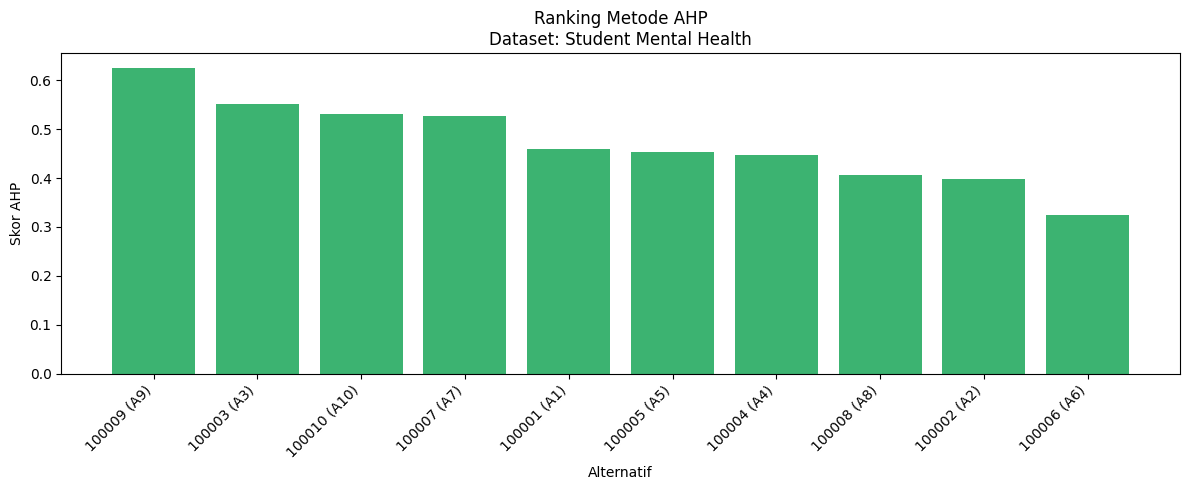

Chart tersimpan: chart_ahp.png


In [ ]:
# =========================================================
# AHP — ANALYTIC HIERARCHY PROCESS
# =========================================================

criteria = [
    'C1 (Stress Level)', 'C2 (Anxiety Score)', 'C3 (Depression Score)',
    'C4 (Academic Pressure)', 'C5 (Social Support)', 'C6 (Screen Time)',
    'C7 (Sleep Quality)', 'C8 (Daily Sleep Hours)',
    'C9 (Coding Hours)', 'C10 (Assignment Deadline)'
]

n = len(criteria)

# =========================================================
# STEP 1 — MATRIKS PERBANDINGAN BERPASANGAN
# Semua bernilai 1 karena bobot sama rata
# =========================================================

matriks_ahp = np.ones((n, n))

df_matriks = pd.DataFrame(matriks_ahp, index=criteria, columns=criteria)
print("--- 1. Matriks Perbandingan Berpasangan ---")
display(df_matriks)

# =========================================================
# STEP 2 — NORMALISASI MATRIKS
# Setiap kolom dibagi jumlah kolomnya
# =========================================================

jumlah_kolom = matriks_ahp.sum(axis=0)
matriks_norm = matriks_ahp / jumlah_kolom

df_norm = pd.DataFrame(matriks_norm, index=criteria, columns=criteria)
print("\n--- 2. Matriks Normalisasi ---")
display(df_norm)

# =========================================================
# STEP 3 — BOBOT PRIORITAS (EIGEN VECTOR)
# Rata-rata setiap baris dari matriks ternormalisasi
# =========================================================

bobot_ahp = matriks_norm.mean(axis=1)

df_bobot = pd.DataFrame({
    'Kriteria': criteria,
    'Bobot AHP': bobot_ahp
})
print("\n--- 3. Bobot Prioritas (Eigen Vector) ---")
display(df_bobot)
print(f"\nTotal Bobot = {bobot_ahp.sum():.4f}")

# =========================================================
# STEP 4 — CONSISTENCY CHECK
# =========================================================

# Hitung lambda max
weighted_sum = matriks_ahp @ bobot_ahp
lambda_values = weighted_sum / bobot_ahp
lambda_max = lambda_values.mean()

# Consistency Index (CI)
CI = (lambda_max - n) / (n - 1)

# Random Index (RI) untuk n=10
RI_table = {1:0.00, 2:0.00, 3:0.58, 4:0.90, 5:1.12,
            6:1.24, 7:1.32, 8:1.41, 9:1.45, 10:1.49}
RI = RI_table[n]

# Consistency Ratio (CR)
CR = CI / RI if RI != 0 else 0

df_consistency = pd.DataFrame({
    'Keterangan': ['Lambda Max', 'CI (Consistency Index)',
                   'RI (Random Index)', 'CR (Consistency Ratio)'],
    'Nilai': [round(lambda_max, 4), round(CI, 4),
              round(RI, 4), round(CR, 4)]
})
print("\n--- 4. Uji Konsistensi ---")
display(df_consistency)

if CR <= 0.10:
    print(f"CR = {CR:.4f} ≤ 0.10 → Matriks KONSISTEN ✓")
else:
    print(f"CR = {CR:.4f} > 0.10 → Matriks TIDAK KONSISTEN ✘")

# =========================================================
# STEP 5 — SKOR AKHIR AHP
# =========================================================

kolom_dataset = [
    'stress_level_num', 'anxiety_score', 'depression_score',
    'academic_pressure_score', 'social_support_score', 'screen_time_hours',
    'sleep_quality_num', 'daily_sleep_hours',
    'coding_hours_per_day', 'assignment_deadline_pressure'
]

is_benefit = [False, False, False, False, True,
              False, True, True, False, False]

student_ids = df['student_id'].head(10).values
alternatives = [f"{sid} (A{i+1})" for i, sid in enumerate(student_ids)]

df_X = pd.DataFrame(
    df[kolom_dataset].head(10).values,
    index=alternatives,
    columns=criteria
)

# Normalisasi per kolom (benefit: x/max, cost: min/x)
df_norm_X = pd.DataFrame(index=alternatives, columns=criteria, dtype=float)

for j, c in enumerate(criteria):
    if is_benefit[j]:
        df_norm_X[c] = df_X[c] / df_X[c].max()
    else:
        df_norm_X[c] = df_X[c].min() / df_X[c]

print("\n--- 5. Matriks Ternormalisasi ---")
display(df_norm_X)

# Hitung skor AHP = normalisasi × bobot
skor_ahp = (df_norm_X * bobot_ahp).sum(axis=1)

df_hasil_ahp = pd.DataFrame({
    'Alternatif': alternatives,
    'Skor AHP'  : skor_ahp.values
})
df_hasil_ahp['Ranking AHP'] = df_hasil_ahp['Skor AHP'].rank(ascending=False).astype(int)
df_hasil_ahp = df_hasil_ahp.sort_values('Ranking AHP').reset_index(drop=True)

print("\n--- 6. Hasil Akhir dan Ranking AHP ---")
display(df_hasil_ahp)

# =========================================================
# STEP 6 — SIMPAN HASIL
# =========================================================

df_hasil_ahp.to_csv('hasil_ahp.csv', index=False)
print("\nTersimpan: hasil_ahp.csv")

# =========================================================
# STEP 7 — VISUALISASI AHP
# =========================================================

plt.figure(figsize=(12, 5))
plt.bar(
    df_hasil_ahp['Alternatif'].astype(str),
    df_hasil_ahp['Skor AHP'],
    color='mediumseagreen'
)
plt.xlabel("Alternatif")
plt.ylabel("Skor AHP")
plt.title("Ranking Metode AHP\nDataset: Student Mental Health")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart_ahp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart tersimpan: chart_ahp.png")

# =========================================================
# STEP 10 — TOPSIS (Technique for Order Preference by Similarity to Ideal Solution)
# =========================================================

TOPSIS adalah metode pengambilan keputusan yang memilih alternatif terbaik
berdasarkan jarak terdekat ke solusi ideal positif dan terjauh dari solusi
ideal negatif. Langkah-langkah TOPSIS meliputi:

1. **Normalisasi Matriks** — Menyamakan skala nilai antar kriteria
2. **Matriks Terbobot** — Mengalikan nilai ternormalisasi dengan bobot kriteria
3. **Solusi Ideal** — Menentukan nilai terbaik (A+) dan terburuk (A-) tiap kriteria
4. **Jarak ke Solusi Ideal** — Menghitung jarak tiap alternatif ke A+ dan A-
5. **Nilai Preferensi** — Menghitung skor akhir: D- / (D+ + D-)
6. **Perangkingan** — Alternatif dengan skor tertinggi adalah yang terbaik

--- 1. Data Mentah ---


,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline)
100001 (A1),3.0,10.0,3.0,4.0,6.0,6.1,2.0,6.8,4.370861,3.0
100002 (A2),3.0,2.0,10.0,8.0,9.0,3.0,1.0,4.7,9.556429,6.0
100003 (A3),1.0,2.0,7.0,8.0,3.0,1.5,3.0,4.8,7.587945,2.0
100004 (A4),3.0,3.0,3.0,4.0,9.0,7.0,1.0,6.7,6.387926,8.0
100005 (A5),3.0,7.0,7.0,6.0,4.0,5.4,3.0,6.7,2.404168,4.0
100006 (A6),3.0,8.0,4.0,9.0,2.0,4.1,1.0,4.8,2.403951,10.0
100007 (A7),1.0,5.0,9.0,9.0,6.0,7.8,2.0,8.0,1.522753,8.0
100008 (A8),2.0,5.0,10.0,3.0,6.0,7.6,1.0,6.3,8.795585,8.0
100009 (A9),1.0,1.0,1.0,7.0,1.0,1.3,2.0,5.4,6.410035,8.0
100010 (A10),2.0,4.0,2.0,4.0,7.0,11.5,1.0,7.0,7.372653,1.0



--- 2. Matriks Normalisasi ---


,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline)
100001 (A1),0.400892,0.580259,0.146735,0.192450,0.321173,0.306548,0.338062,0.346093,0.219784,0.146038
100002 (A2),0.400892,0.116052,0.489116,0.384900,0.481759,0.150761,0.169031,0.239211,0.480534,0.292075
100003 (A3),0.133631,0.116052,0.342381,0.384900,0.160586,0.075381,0.507093,0.244301,0.381551,0.097358
100004 (A4),0.400892,0.174078,0.146735,0.192450,0.481759,0.351777,0.169031,0.341003,0.321209,0.389434
100005 (A5),0.400892,0.406181,0.342381,0.288675,0.214115,0.271370,0.507093,0.341003,0.120891,0.194717
100006 (A6),0.400892,0.464207,0.195646,0.433013,0.107058,0.206041,0.169031,0.244301,0.120880,0.486792
100007 (A7),0.133631,0.290129,0.440204,0.433013,0.321173,0.391980,0.338062,0.407168,0.076570,0.389434
100008 (A8),0.267261,0.290129,0.489116,0.144338,0.321173,0.381929,0.169031,0.320645,0.442276,0.389434
100009 (A9),0.133631,0.058026,0.048912,0.336788,0.053529,0.065330,0.338062,0.274839,0.322321,0.389434
100010 (A10),0.267261,0.232104,0.097823,0.192450,0.374701,0.577919,0.169031,0.356272,0.370725,0.048679



--- 3. Matriks Ternormalisasi Terbobot ---


...


--- 5. Jarak ke Solusi Ideal ---


,Alternatif,D+ (Jarak ke A+),D- (Jarak ke A-)
0,100001 (A1),0.070873,0.073788
1,100002 (A2),0.083586,0.078839
2,100003 (A3),0.061035,0.092225
3,100004 (A4),0.068808,0.078729
4,100005 (A5),0.066434,0.072920
5,100006 (A6),0.091444,0.060838
6,100007 (A7),0.075332,0.070260
7,100008 (A8),0.087359,0.055945
8,100009 (A9),0.066559,0.093504
9,100010 (A10),0.072834,0.081909



--- 6. Nilai Preferensi dan Ranking TOPSIS ---


,Alternatif,D+,D-,Skor TOPSIS,Ranking TOPSIS
0,100003 (A3),0.061035,0.092225,0.601755,1
1,100009 (A9),0.066559,0.093504,0.584170,2
2,100004 (A4),0.068808,0.078729,0.533621,3
3,100010 (A10),0.072834,0.081909,0.529322,4
4,100005 (A5),0.066434,0.072920,0.523268,5
5,100001 (A1),0.070873,0.073788,0.510074,6
6,100002 (A2),0.083586,0.078839,0.485387,7
7,100007 (A7),0.075332,0.070260,0.482583,8
8,100006 (A6),0.091444,0.060838,0.399510,9
9,100008 (A8),0.087359,0.055945,0.390394,10



Tersimpan: hasil_topsis.csv


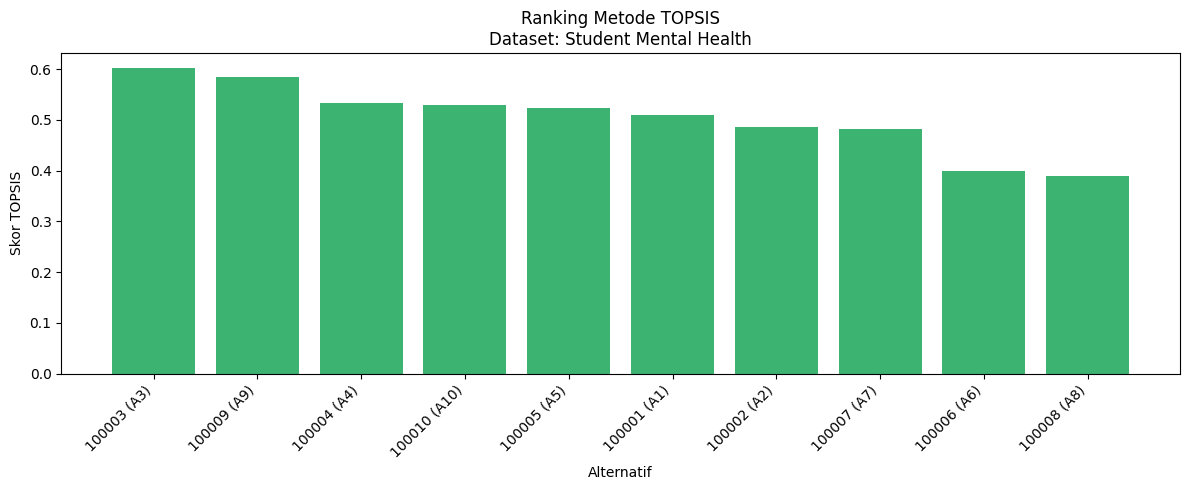

Chart tersimpan: chart_topsis.png


In [ ]:
# =========================================================
# TOPSIS — Technique for Order Preference by
#           Similarity to Ideal Solution
# =========================================================

criteria = [
    'C1 (Stress Level)', 'C2 (Anxiety Score)', 'C3 (Depression Score)',
    'C4 (Academic Pressure)', 'C5 (Social Support)', 'C6 (Screen Time)',
    'C7 (Sleep Quality)', 'C8 (Daily Sleep Hours)',
    'C9 (Coding Hours)', 'C10 (Assignment Deadline)'
]

is_benefit = [False, False, False, False, True,
              False, True, True, False, False]

weights = np.array([0.10] * 10)

kolom_dataset = [
    'stress_level_num', 'anxiety_score', 'depression_score',
    'academic_pressure_score', 'social_support_score', 'screen_time_hours',
    'sleep_quality_num', 'daily_sleep_hours',
    'coding_hours_per_day', 'assignment_deadline_pressure'
]

student_ids = df['student_id'].head(10).values
alternatives = [f"{sid} (A{i+1})" for i, sid in enumerate(student_ids)]

df_X = pd.DataFrame(
    df[kolom_dataset].head(10).values,
    index=alternatives,
    columns=criteria,
    dtype=float
)

print("--- 1. Data Mentah ---")
display(df_X)

# =========================================================
# STEP 2 — NORMALISASI MATRIKS
# r_ij = x_ij / sqrt(sum(x_ij^2))
# =========================================================

norm_denom = np.sqrt((df_X ** 2).sum(axis=0))
df_R = df_X / norm_denom

print("\n--- 2. Matriks Normalisasi ---")
display(df_R)

# =========================================================
# STEP 3 — MATRIKS TERBOBOT
# v_ij = w_j * r_ij
# =========================================================

df_V = df_R * weights

print("\n--- 3. Matriks Ternormalisasi Terbobot ---")
display(df_V)

# =========================================================
# STEP 4 — SOLUSI IDEAL POSITIF (A+) DAN NEGATIF (A-)
# =========================================================

A_plus  = []
A_minus = []

for j, c in enumerate(criteria):
    if is_benefit[j]:
        A_plus.append(df_V[c].max())   # benefit: max = ideal positif
        A_minus.append(df_V[c].min())  # benefit: min = ideal negatif
    else:
        A_plus.append(df_V[c].min())   # cost: min = ideal positif
        A_minus.append(df_V[c].max())  # cost: max = ideal negatif

A_plus  = np.array(A_plus)
A_minus = np.array(A_minus)

df_ideal = pd.DataFrame({
    'Kriteria'          : criteria,
    'A+ (Ideal Positif)': A_plus,
    'A- (Ideal Negatif)': A_minus
})
print("\n--- 4. Solusi Ideal Positif (A+) dan Negatif (A-) ---")
display(df_ideal)

# =========================================================
# STEP 5 — JARAK KE SOLUSI IDEAL
# D+ = sqrt(sum((v_ij - A+_j)^2))
# D- = sqrt(sum((v_ij - A-_j)^2))
# =========================================================

D_plus  = np.sqrt(((df_V.values - A_plus)  ** 2).sum(axis=1))
D_minus = np.sqrt(((df_V.values - A_minus) ** 2).sum(axis=1))

df_jarak = pd.DataFrame({
    'Alternatif': alternatives,
    'D+ (Jarak ke A+)': D_plus,
    'D- (Jarak ke A-)': D_minus
})
print("\n--- 5. Jarak ke Solusi Ideal ---")
display(df_jarak)

# =========================================================
# STEP 6 — NILAI PREFERENSI (SKOR TOPSIS)
# V_i = D- / (D+ + D-)
# =========================================================

skor_topsis = D_minus / (D_plus + D_minus)

df_hasil_topsis = pd.DataFrame({
    'Alternatif'  : alternatives,
    'D+'          : D_plus,
    'D-'          : D_minus,
    'Skor TOPSIS' : skor_topsis
})
df_hasil_topsis['Ranking TOPSIS'] = (
    df_hasil_topsis['Skor TOPSIS']
    .rank(ascending=False)
    .astype(int)
)
df_hasil_topsis = df_hasil_topsis.sort_values('Ranking TOPSIS').reset_index(drop=True)

print("\n--- 6. Nilai Preferensi dan Ranking TOPSIS ---")
display(df_hasil_topsis)

# =========================================================
# STEP 7 — SIMPAN HASIL
# =========================================================

df_hasil_topsis[['Alternatif', 'Skor TOPSIS', 'Ranking TOPSIS']].to_csv(
    'hasil_topsis.csv', index=False
)
print("\nTersimpan: hasil_topsis.csv")

# =========================================================
# STEP 8 — VISUALISASI TOPSIS
# =========================================================

plt.figure(figsize=(12, 5))
plt.bar(
    df_hasil_topsis['Alternatif'].astype(str),
    df_hasil_topsis['Skor TOPSIS'],
    color='mediumseagreen'
)
plt.xlabel("Alternatif")
plt.ylabel("Skor TOPSIS")
plt.title("Ranking Metode TOPSIS\nDataset: Student Mental Health")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart_topsis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart tersimpan: chart_topsis.png")

# =========================================================
# STEP 11 — TABEL PERBANDINGAN 3 METODE (SAW, EDAS, AHP, TOPSIS)
# =========================================================


Bagian ini menggabungkan hasil perangkingan dari keempat metode ke dalam
satu tabel untuk memudahkan analisis perbandingan. Perbandingan ini bertujuan:

- Melihat konsistensi ranking antar metode
- Mengidentifikasi alternatif terbaik berdasarkan mayoritas metode
- Menganalisis perbedaan hasil akibat pendekatan normalisasi yang berbeda

Jika keempat metode menghasilkan ranking yang sama, maka hasil keputusan
dapat dinyatakan konsisten dan dapat dipercaya.

In [ ]:
# =========================================================
# PERBANDINGAN 4 METODE
# =========================================================

# Ensure df_saw and df_edas 'Alternatif' are strings for merging
df_saw['Alternatif'] = df_saw['Alternatif'].astype(str)
df_edas['Alternatif'] = df_edas['Alternatif'].astype(str)

# Create a temporary DataFrame to hold alternatives and their clean student_ids
# This assumes 'alternatives' list is in the order 'student_id (A#)'
temp_alternatives_df = pd.DataFrame({
    'Alternatif_full': alternatives,
    'Alternatif_clean': [alt.split(' ')[0] for alt in alternatives] # Extract clean student_id
})

# Align df_saw scores/rankings with the 'alternatives' order
df_saw_aligned = pd.merge(
    temp_alternatives_df,
    df_saw.rename(columns={'Alternatif': 'Alternatif_clean'}), # Rename for merge
    on='Alternatif_clean',
    how='left'
)
skor_saw = df_saw_aligned['Skor_SAW'].values
ranking_saw = df_saw_aligned['Ranking_SAW'].values

# Align df_edas scores/rankings with the 'alternatives' order
df_edas_aligned = pd.merge(
    temp_alternatives_df,
    df_edas.rename(columns={'Alternatif': 'Alternatif_clean'}), # Rename for merge
    on='Alternatif_clean',
    how='left'
)
AS = df_edas_aligned['Skor_EDAS'].values
df_final = pd.DataFrame({'Peringkat': df_edas_aligned['Ranking_EDAS'].values})
# --- End of Fix ---

df_all = pd.DataFrame({'Alternatif': alternatives})

# Tambah hasil SAW
df_saw_temp = pd.DataFrame({
    'Alternatif': alternatives,
    'Skor_SAW'  : skor_saw,
    'Ranking_SAW': ranking_saw
})

# Tambah hasil EDAS
df_edas_temp = pd.DataFrame({
    'Alternatif' : alternatives,
    'Skor_EDAS'  : AS,
    'Ranking_EDAS': df_final['Peringkat'].values
})

# Tambah hasil AHP
df_ahp_temp = pd.DataFrame({
    'Alternatif': alternatives,
    'Skor_AHP'  : skor_ahp.values,
    'Ranking_AHP': pd.Series(skor_ahp.values).rank(ascending=False).astype(int).values
})

# Tambah hasil TOPSIS
df_topsis_temp = pd.DataFrame({
    'Alternatif'   : alternatives,
    'Skor_TOPSIS'  : skor_topsis,
    'Ranking_TOPSIS': pd.Series(skor_topsis).rank(ascending=False).astype(int).values
})

# Merge semua — semua bertipe string karena dari variabel alternatives
df_all = df_saw_temp.merge(df_edas_temp,   on='Alternatif')
df_all = df_all.merge(df_ahp_temp,         on='Alternatif')
df_all = df_all.merge(df_topsis_temp,      on='Alternatif')

df_all = df_all.sort_values('Ranking_SAW').reset_index(drop=True)

print("=== TABEL PERBANDINGAN 4 METODE ===")
display(df_all)

# Simpan
df_all.to_csv('hasil_perbandingan_4_metode.csv', index=False)
print("Tersimpan: hasil_perbandingan_4_metode.csv")

=== TABEL PERBANDINGAN 4 METODE ===


,Alternatif,Skor_SAW,Ranking_SAW,Skor_EDAS,Ranking_EDAS,Skor_AHP,Ranking_AHP,Skor_TOPSIS,Ranking_TOPSIS
0,100009 (A9),0.624391,1,0.770590,2,0.624391,1,0.584170,2
1,100003 (A3),0.551854,2,0.853757,1,0.551854,2,0.601755,1
2,100010 (A10),0.530570,3,0.708960,3,0.530570,3,0.529322,4
3,100007 (A7),0.526944,4,0.336109,9,0.526944,4,0.482583,8
4,100001 (A1),0.459484,5,0.514538,6,0.459484,5,0.510074,6
5,100005 (A5),0.452511,6,0.433435,8,0.452511,6,0.523268,5
6,100004 (A4),0.446993,7,0.616487,4,0.446993,7,0.533621,3
7,100008 (A8),0.405668,8,0.435036,7,0.405668,8,0.390394,10
8,100002 (A2),0.398851,9,0.574351,5,0.398851,9,0.485387,7
9,100006 (A6),0.324773,10,0.075510,10,0.324773,10,0.399510,9


Tersimpan: hasil_perbandingan_4_metode.csv


In [ ]:
# Tambahkan ini untuk cek konsistensi otomatis
print("=== KONSISTENSI RANKING ===\n")

metode = ['Ranking_SAW', 'Ranking_EDAS', 'Ranking_AHP', 'Ranking_TOPSIS']
pasangan = [('SAW','EDAS'), ('SAW','AHP'), ('SAW','TOPSIS'),
            ('EDAS','AHP'), ('EDAS','TOPSIS'), ('AHP','TOPSIS')]

for (m1, m2) in pasangan:
    sama = (df_all[f'Ranking_{m1}'] == df_all[f'Ranking_{m2}']).sum()
    print(f"{m1} vs {m2}: {sama}/10 alternatif ranking sama")

print("\n=== ALTERNATIF TERBAIK PER METODE ===")
for m in ['SAW', 'EDAS', 'AHP', 'TOPSIS']:
    terbaik = df_all.loc[df_all[f'Ranking_{m}'] == 1, 'Alternatif'].values[0]
    print(f"{m:<8}: {terbaik}")

=== KONSISTENSI RANKING ===

SAW vs EDAS: 2/10 alternatif ranking sama
SAW vs AHP: 10/10 alternatif ranking sama
SAW vs TOPSIS: 0/10 alternatif ranking sama
EDAS vs AHP: 2/10 alternatif ranking sama
EDAS vs TOPSIS: 3/10 alternatif ranking sama
AHP vs TOPSIS: 0/10 alternatif ranking sama

=== ALTERNATIF TERBAIK PER METODE ===
SAW     : 100009 (A9)
EDAS    : 100003 (A3)
AHP     : 100009 (A9)
TOPSIS  : 100003 (A3)
